# 3.5 Entrenamiento y selección del modelo óptimo
## Predicción del precio de la Papa Blanca — GMML (horizonte principal: 7 días)

**Grupo 6 — Inteligencia Artificial (1INF24)**

Este cuadernillo continúa el pipeline a partir del archivo `Dataset_Preprocesado_Papa_Blanca.csv`

Contenido del cuadernillo:

1. Carga del dataset preprocesado y reconstrucción de la serie diaria.
2. Ingeniería de características temporales (rezagos, ventanas móviles, diferencias, calendario, participación regional).
3. Definición del target de cambio de precio (Δy) a 7 días y separación cronológica 80/20.
4. Entrenamiento de los 5 modelos: **Naive_t, Ridge, Random Forest, LightGBM, SVR-RBF** con `TimeSeriesSplit`.
5. Evaluación con MAE, RMSE, MAPE, sMAPE, R².
6. Evaluación complementaria de dirección (sube / no sube) con matriz de confusión.
7. Importancia de variables (Random Forest).
8. Escenario complementario a horizonte de 1 día.

> **Nota importante sobre la columna `fecha`.** En el archivo `Dataset_Preprocesado_Papa_Blanca.csv`
> la columna `fecha` original ya fue transformada a `fecha_sin` / `fecha_cos` (codificación cíclica). Este
> cuadernillo reconstruye el orden cronológico agrupando filas consecutivas que comparten el mismo
> `(fecha_sin, fecha_cos)` — el archivo está ordenado por fecha, por lo que esos bloques consecutivos
> corresponden a un mismo día de mercado — y sintetiza un calendario continuo desde `2022-01-01`


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              confusion_matrix, precision_score, recall_score,
                              f1_score, accuracy_score, ConfusionMatrixDisplay)

try:
    from lightgbm import LGBMRegressor
    LGBM_OK = True
except ImportError:
    LGBM_OK = False
    print("LightGBM no está instalado. Ejecuta: pip install lightgbm")

RANDOM_STATE = 42
HORIZON = 7          # horizonte principal en días
TEST_SIZE = 0.20      # separación cronológica 80/20
N_SPLITS_CV = 5        # TimeSeriesSplit

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True


## 1. Carga de datos y reconstrucción de la serie diaria

### 1.1 Carga del dataset preprocesado

In [ ]:
RUTA_DATASET = "Dataset_Preprocesado_Papa_Blanca.csv"  # ajustar ruta si es necesario

df = pd.read_csv(RUTA_DATASET)
print("Dimensiones:", df.shape)
df.head()


Dimensiones: (18954, 61)


,volumen,volumen_log,precio_promedio_kg,indice_precio_diesel,lluvia_hoy,dias_con_helada_en_cultivo,T2M_MIN,T2M_MAX,zona_acobamba,zona_ambo,...,zona_pasco,zona_pisco,zona_sanchez carrion,zona_santiago de chuco,zona_tarma,zona_tayacaja,zona_yauli,zona_yauyos,fecha_sin,fecha_cos
0,18.0,2.944439,0.94,88.4916,12.51,0.0,2.17,11.14,0,0,...,1,0,0,0,0,0,0,0,0.552435,0.833556
1,10.0,2.397895,0.94,88.4916,12.67,0.0,2.17,11.14,0,0,...,0,0,0,0,0,0,0,0,0.552435,0.833556
2,60.0,4.110874,0.94,88.4916,0.45,0.0,16.94,23.19,0,0,...,0,0,0,0,0,0,0,0,0.552435,0.833556
3,19.0,2.995732,0.94,88.4916,3.34,0.0,18.74,26.20,0,0,...,0,0,0,0,0,0,0,0,0.552435,0.833556
4,93.0,4.543295,0.94,88.4916,1.43,0.0,20.73,23.36,0,0,...,0,0,0,0,0,0,0,0,0.552435,0.833556


### 1.2 Reconstrucción del orden cronológico y agregación a frecuencia diaria

El archivo trae una fila por combinación *(zona, día)*. Siguiendo la metodología descrita en la
sección de preprocesamiento del informe final (*"la frecuencia final se definió como diaria... el
precio se tomó como valor diario de mercado, el volumen se sumó y las variables
climáticas/económicas se promediaron"*), agregamos a nivel día:

- `precio_promedio_kg` → es el mismo valor para todas las filas de un día (precio único de mercado), se toma tal cual.
- `volumen` → se suma (`volumen_total`) y se recalcula `volumen_log`.
- `indice_precio_diesel`, `lluvia_hoy`, `T2M_MIN`, `T2M_MAX`, `dias_con_helada_en_cultivo` → se promedian entre zonas.
- `n_zonas_reportantes` → número de zonas que reportaron abastecimiento ese día (proxy de dispersión de oferta).
- Participación de volumen de las **zonas de mayor abastecimiento histórico** (`participaciones regionales`), para replicar la idea de participación de las principales regiones de origen que menciona el informe.

In [ ]:
# --- Reconstruir bloques consecutivos = mismo día de mercado ---
key = list(zip(df['fecha_sin'].round(6), df['fecha_cos'].round(6)))
day_id, g, cur = [], 0, key[0]
for k in key:
    if k != cur:
        g += 1
        cur = k
    day_id.append(g)
df['day_id'] = day_id

n_days = df['day_id'].nunique()
print(f"Días de mercado reconstruidos: {n_days}")

# Calendario sintético continuo (ver nota metodológica al inicio del cuadernillo)
fecha_index = pd.date_range('2022-01-01', periods=n_days, freq='D')
fecha_map = dict(zip(range(n_days), fecha_index))

# Zonas con mayor volumen histórico -> proxy de "principales regiones de origen"
zona_cols = [c for c in df.columns if c.startswith('zona_')]
vol_por_zona = {z: df.loc[df[z] == 1, 'volumen'].sum() for z in zona_cols}
TOP_ZONAS = pd.Series(vol_por_zona).sort_values(ascending=False).head(5).index.tolist()
print("Zonas principales por volumen histórico:", [z.replace('zona_', '') for z in TOP_ZONAS])


Días de mercado reconstruidos: 1491
Zonas principales por volumen histórico: ['huanuco', 'huancayo', 'tarma', 'huamanga', 'arequipa']


In [ ]:
def agregar_dia(g):
    vol_total = g['volumen'].sum()
    out = {
        'volumen_total': vol_total,
        'precio_promedio_kg': g['precio_promedio_kg'].iloc[0],
        'indice_precio_diesel': g['indice_precio_diesel'].mean(),
        'lluvia_hoy': g['lluvia_hoy'].mean(),
        'dias_con_helada_en_cultivo': g['dias_con_helada_en_cultivo'].mean(),
        'T2M_MIN': g['T2M_MIN'].mean(),
        'T2M_MAX': g['T2M_MAX'].mean(),
        'fecha_sin': g['fecha_sin'].iloc[0],
        'fecha_cos': g['fecha_cos'].iloc[0],
        'n_zonas_reportantes': g.shape[0],
    }
    for z in TOP_ZONAS:
        zvol = g.loc[g[z] == 1, 'volumen'].sum()
        out[f"part_{z.replace('zona_', '')}"] = (zvol / vol_total) if vol_total > 0 else 0.0
    return pd.Series(out)

daily = df.groupby('day_id').apply(agregar_dia).reset_index()
daily['fecha'] = daily['day_id'].map(fecha_map)
daily['volumen_log'] = np.log1p(daily['volumen_total'])
daily = daily.sort_values('fecha').reset_index(drop=True)

print("Serie diaria:", daily.shape)
print("Rango de fechas:", daily['fecha'].min().date(), "->", daily['fecha'].max().date())
daily.head()


Serie diaria: (1491, 18)
Rango de fechas: 2022-01-01 -> 2026-01-30


,day_id,volumen_total,precio_promedio_kg,indice_precio_diesel,lluvia_hoy,dias_con_helada_en_cultivo,T2M_MIN,T2M_MAX,fecha_sin,fecha_cos,n_zonas_reportantes,part_huanuco,part_huancayo,part_tarma,part_huamanga,part_arequipa,fecha,volumen_log
0,0,2713.0,0.94,88.4916,5.660588,0.235294,7.195294,16.248235,0.552435,0.833556,17.0,0.410247,0.121268,0.168817,0.042757,0.106524,2022-01-01,7.906179
1,1,596.0,0.93,88.4916,3.694286,0.000000,8.564286,16.421429,0.538005,0.842942,7.0,0.365772,0.080537,0.060403,0.000000,0.402685,2022-01-02,6.391917
2,2,1362.0,0.85,88.4916,7.085556,0.000000,8.981111,15.873333,0.523416,0.852078,9.0,0.436123,0.213656,0.168135,0.056535,0.044053,2022-01-03,7.217443
3,3,1533.0,0.85,89.1625,2.870000,0.133333,9.074667,16.604000,0.508671,0.860961,15.0,0.323549,0.164384,0.161122,0.026093,0.111546,2022-01-04,7.335634
4,4,1812.0,0.84,89.1625,1.531667,0.111111,8.619444,17.925556,0.493776,0.869589,18.0,0.261589,0.146247,0.099338,0.028698,0.177704,2022-01-05,7.502738


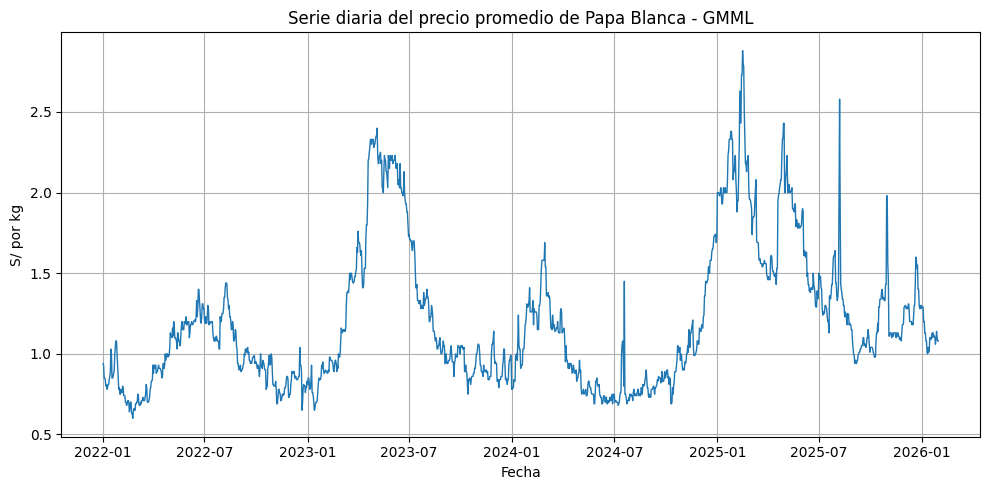

In [ ]:
fig, ax = plt.subplots()
ax.plot(daily['fecha'], daily['precio_promedio_kg'], linewidth=1)
ax.set_title('Serie diaria del precio promedio de Papa Blanca - GMML')
ax.set_xlabel('Fecha')
ax.set_ylabel('S/ por kg')
plt.tight_layout()
plt.show()


## 2. Ingeniería de características temporales

Se replican las decisiones de la sección 4 del informe: rezagos de 1, 2, 3, 7, 14, 30, 60 y 90 días;
medias móviles de 3, 7, 14, 30, 60 y 90 días; desviaciones móviles de 7 y 30 días; diferencias de
precio a 3/7/14/30 días; variable calendario cíclica (`fecha_sin`, `fecha_cos`); volumen y su
diferencia; y participación de zonas rezagada 7 días (el clima y la oferta impactan el precio con
retraso, no el mismo día).

In [ ]:
HORIZONTES_LAG = [1, 2, 3, 7, 14, 30, 60, 90]
VENTANAS_MEDIA = [3, 7, 14, 30, 60, 90]
VENTANAS_STD = [7, 30]
DELTAS = [3, 7, 14, 30]

d = daily.set_index('fecha').copy()
precio = d['precio_promedio_kg']

for L in HORIZONTES_LAG:
    d[f'precio_lag{L}'] = precio.shift(L)

for W in VENTANAS_MEDIA:
    d[f'precio_roll{W}'] = precio.shift(1).rolling(W).mean()

for W in VENTANAS_STD:
    d[f'precio_std{W}'] = precio.shift(1).rolling(W).std()

for L in DELTAS:
    d[f'precio_delta{L}'] = precio - precio.shift(L)

d['volumen_log_lag1'] = d['volumen_log'].shift(1)
d['volumen_delta1'] = d['volumen_total'] - d['volumen_total'].shift(1)
d['diesel_lag7'] = d['indice_precio_diesel'].shift(7)
d['lluvia_lag14'] = d['lluvia_hoy'].shift(14)
d['helada_lag30'] = d['dias_con_helada_en_cultivo'].shift(30)

part_cols = [c for c in d.columns if c.startswith('part_')]
for c in part_cols:
    d[f'{c}_lag7'] = d[c].shift(7)

d = d.rename(columns={'precio_promedio_kg': 'precio'})


In [ ]:
def construir_dataset_modelo(d, horizon):
    """Arma el vector de entrada X y el target delta de precio a `horizon` días,
    evitando fuga de información (todas las variables usadas son conocidas hasta t)."""
    d = d.copy()
    d['target_delta'] = d['precio'].shift(-horizon) - d['precio']
    d['precio_futuro'] = d['precio'].shift(-horizon)

    excluir = {'volumen_total', 'fecha_sin_raw', 'target_delta', 'precio_futuro'}
    excluir |= {c for c in d.columns if c.startswith('part_') and not c.endswith('_lag7')}

    feature_cols = [c for c in d.columns if c not in excluir]
    feature_cols = [c for c in feature_cols if c not in ('target_delta', 'precio_futuro')]

    model_df = d.dropna(subset=feature_cols + ['target_delta']).copy()
    return model_df, feature_cols

model_df, feature_cols = construir_dataset_modelo(d, HORIZON)
print(f"Observaciones utilizables (horizonte {HORIZON}d): {len(model_df)}")
print(f"N° de variables (features): {len(feature_cols)}")
feature_cols


Observaciones utilizables (horizonte 7d): 1394
N° de variables (features): 41


['day_id',
 'precio',
 'indice_precio_diesel',
 'lluvia_hoy',
 'dias_con_helada_en_cultivo',
 'T2M_MIN',
 'T2M_MAX',
 'fecha_sin',
 'fecha_cos',
 'n_zonas_reportantes',
 'volumen_log',
 'precio_lag1',
 'precio_lag2',
 'precio_lag3',
 'precio_lag7',
 'precio_lag14',
 'precio_lag30',
 'precio_lag60',
 'precio_lag90',
 'precio_roll3',
 'precio_roll7',
 'precio_roll14',
 'precio_roll30',
 'precio_roll60',
 'precio_roll90',
 'precio_std7',
 'precio_std30',
 'precio_delta3',
 'precio_delta7',
 'precio_delta14',
 'precio_delta30',
 'volumen_log_lag1',
 'volumen_delta1',
 'diesel_lag7',
 'lluvia_lag14',
 'helada_lag30',
 'part_huanuco_lag7',
 'part_huancayo_lag7',
 'part_tarma_lag7',
 'part_huamanga_lag7',
 'part_arequipa_lag7']

## 3. Separación cronológica 80/20 y validación temporal

Se usa una separación **cronológica** (no aleatoria) para evitar fuga de información: el bloque
inicial (80%) se destina a entrenamiento/validación y el bloque más reciente (20%) se reserva como
prueba final. La validación interna durante el ajuste de hiperparámetros se hace con
`TimeSeriesSplit` de 5 pliegues sobre el bloque de entrenamiento.

In [ ]:
n = len(model_df)
split_idx = int(n * (1 - TEST_SIZE))

train_df = model_df.iloc[:split_idx]
test_df = model_df.iloc[split_idx:]

print(f"Entrenamiento: {train_df.index.min().date()} -> {train_df.index.max().date()}  ({len(train_df)} obs.)")
print(f"Prueba:        {test_df.index.min().date()} -> {test_df.index.max().date()}  ({len(test_df)} obs.)")

X_train, y_train_delta = train_df[feature_cols], train_df['target_delta']
X_test, y_test_delta = test_df[feature_cols], test_df['target_delta']

precio_train_t = train_df['precio']
precio_test_t = test_df['precio']
y_test_precio = test_df['precio_futuro']   # precio real en t+7 (para métricas en escala S//kg)

tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)


Entrenamiento: 2022-04-01 -> 2025-04-19  (1115 obs.)
Prueba:        2025-04-20 -> 2026-01-23  (279 obs.)


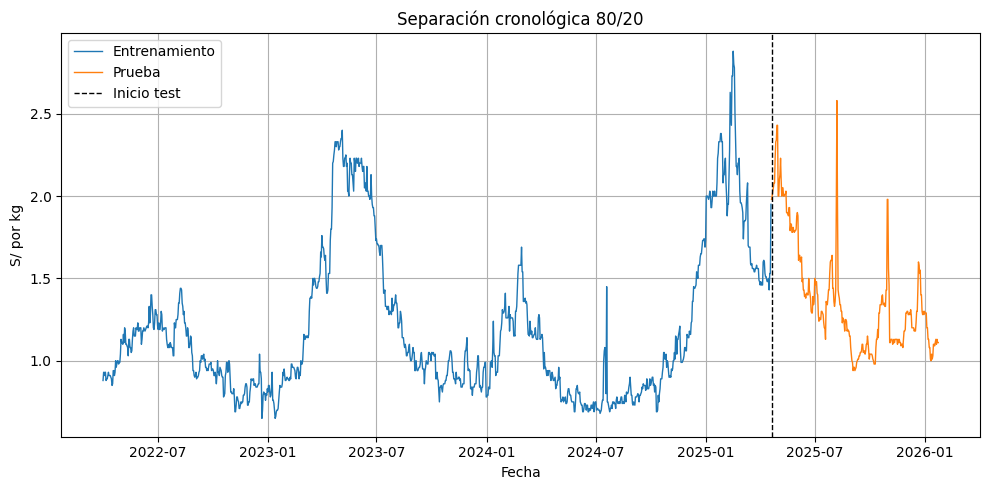

In [ ]:
fig, ax = plt.subplots()
ax.plot(train_df.index, train_df['precio'], label='Entrenamiento', linewidth=1)
ax.plot(test_df.index, test_df['precio'], label='Prueba', linewidth=1, color='tab:orange')
ax.axvline(test_df.index.min(), color='k', linestyle='--', linewidth=1, label='Inicio test')
ax.set_title('Separación cronológica 80/20')
ax.set_xlabel('Fecha'); ax.set_ylabel('S/ por kg')
ax.legend()
plt.tight_layout(); plt.show()


## 4. Métricas de evaluación

Se predice el **cambio de precio** Δy = precio(t+7) − precio(t) y se reconstruye el precio
pronosticado como `precio(t) + Δy_pred`. Todas las métricas de error (MAE, RMSE, MAPE, sMAPE, R²)
se calculan sobre el **precio reconstruido**, en la escala S/ por kg, para que sean directamente
comparables entre modelos y con el baseline de persistencia.

In [ ]:
def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100

def evaluar_regresion(y_true, y_pred, nombre):
    return {
        'Modelo': nombre,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mape(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }


## 5. Entrenamiento de los 5 modelos

| Modelo | Familia | Justificación |
|---|---|---|
| **Naive_t** | Persistencia | Referencia mínima: precio futuro igual al actual. |
| **Ridge** | Regresión regularizada | Baseline lineal; controla complejidad con L2. |
| **Random Forest** | Ensamble bagging | Captura no linealidad y reduce varianza promediando árboles. |
| **LightGBM** | Gradient boosting | Árboles secuenciales, buen desempeño en datos tabulares. |
| **SVR-RBF** | Kernel | Modelo no lineal sensible a escala; comparación clásica. |

Ridge y SVR se evalúan dentro de `Pipeline` con `StandardScaler` (sensibles a escala). El ajuste de
hiperparámetros usa `GridSearchCV` con `TimeSeriesSplit` y `neg_root_mean_squared_error` como
criterio, igual que en el informe.

In [ ]:
predicciones = {}
mejores_params = {}


### 5.1 Naive_t (baseline de persistencia)

`precio(t+7) = precio(t)`, es decir, delta = 0.

In [ ]:
pred_naive = precio_test_t.values  # delta predicho = 0
predicciones['Naive_t'] = pred_naive


### 5.2 Ridge

In [ ]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=RANDOM_STATE)),
])

ridge_param_grid = {'ridge__alpha': [0.1, 1, 5, 10, 50, 100]}

ridge_grid = GridSearchCV(
    ridge_pipe, ridge_param_grid, cv=tscv,
    scoring='neg_root_mean_squared_error', n_jobs=-1,
)
ridge_grid.fit(X_train, y_train_delta)

mejores_params['Ridge'] = ridge_grid.best_params_
predicciones['Ridge'] = precio_test_t.values + ridge_grid.predict(X_test)

print("Mejor alpha (Ridge):", ridge_grid.best_params_)


Mejor alpha (Ridge): {'ridge__alpha': 100}


### 5.3 Random Forest

In [ ]:
# n_jobs=1 en el estimador base: el paralelismo se hace a nivel de GridSearchCV (n_jobs=-1).
# Usar n_jobs=-1 en ambos genera paralelismo anidado y en la práctica lo hace más lento.
rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)

rf_param_grid = {
    'n_estimators': [300],
    'max_depth': [8, None],
    'min_samples_leaf': [2, 5],
}

rf_grid = GridSearchCV(
    rf, rf_param_grid, cv=tscv,
    scoring='neg_root_mean_squared_error', n_jobs=-1,
)
rf_grid.fit(X_train, y_train_delta)

mejores_params['Random Forest'] = rf_grid.best_params_
predicciones['Random Forest'] = precio_test_t.values + rf_grid.predict(X_test)

print("Mejores hiperparámetros (RF):", rf_grid.best_params_)


Mejores hiperparámetros (RF): {'max_depth': 8, 'min_samples_leaf': 2, 'n_estimators': 300}


### 5.4 LightGBM

In [ ]:
if LGBM_OK:
    # n_jobs=1 en el estimador base (LightGBM usa -1 por defecto): el paralelismo
    # se hace a nivel de GridSearchCV (n_jobs=-1) para evitar paralelismo anidado.
    lgbm = LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1)

    lgbm_param_grid = {
        'n_estimators': [300],
        'num_leaves': [15, 31],
        'learning_rate': [0.05, 0.1],
    }

    lgbm_grid = GridSearchCV(
        lgbm, lgbm_param_grid, cv=tscv,
        scoring='neg_root_mean_squared_error', n_jobs=-1,
    )
    lgbm_grid.fit(X_train, y_train_delta)

    mejores_params['LightGBM'] = lgbm_grid.best_params_
    predicciones['LightGBM'] = precio_test_t.values + lgbm_grid.predict(X_test)

    print("Mejores hiperparámetros (LightGBM):", lgbm_grid.best_params_)
else:
    print("LightGBM no disponible: instala con `pip install lightgbm` y vuelve a ejecutar esta celda.")


Mejores hiperparámetros (LightGBM): {'learning_rate': 0.05, 'n_estimators': 300, 'num_leaves': 31}


### 5.5 SVR-RBF

In [ ]:
svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf')),
])

svr_param_grid = {
    'svr__C': [1, 10],
    'svr__epsilon': [0.01, 0.05],
    'svr__gamma': ['scale'],
}

svr_grid = GridSearchCV(
    svr_pipe, svr_param_grid, cv=tscv,
    scoring='neg_root_mean_squared_error', n_jobs=-1,
)
svr_grid.fit(X_train, y_train_delta)

mejores_params['SVR-RBF'] = svr_grid.best_params_
predicciones['SVR-RBF'] = precio_test_t.values + svr_grid.predict(X_test)

print("Mejores hiperparámetros (SVR-RBF):", svr_grid.best_params_)


Mejores hiperparámetros (SVR-RBF): {'svr__C': 1, 'svr__epsilon': 0.05, 'svr__gamma': 'scale'}


## 6. Resultados — comparación de modelos (horizonte 7 días)

### 6.1 Distribución de RMSE en validación cruzada temporal (Figura 5 del informe)

In [ ]:
from sklearn.base import clone

def rmse_por_pliegue(estimator, X, y, cv):
    scores = []
    for tr_idx, val_idx in cv.split(X):
        est = clone(estimator)
        est.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = est.predict(X.iloc[val_idx])
        scores.append(np.sqrt(mean_squared_error(y.iloc[val_idx], pred)))
    return scores

modelos_finales = {
    'Ridge': ridge_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'SVR-RBF': svr_grid.best_estimator_,
}
if LGBM_OK:
    modelos_finales['LightGBM'] = lgbm_grid.best_estimator_

# Naive_t como referencia: RMSE por pliegue prediciendo delta=0
naive_scores = []
for tr_idx, val_idx in tscv.split(X_train):
    y_val = y_train_delta.iloc[val_idx]
    naive_scores.append(np.sqrt(mean_squared_error(y_val, np.zeros(len(y_val)))))

cv_scores = {'Naive_t': naive_scores}
for nombre, est in modelos_finales.items():
    cv_scores[nombre] = rmse_por_pliegue(est, X_train, y_train_delta, tscv)

cv_df = pd.DataFrame(cv_scores)
print(cv_df)


    Naive_t     Ridge  Random Forest   SVR-RBF  LightGBM
0  0.128273  0.185794       0.131671  0.137139  0.145444
1  0.166045  0.215542       0.163339  0.167855  0.184682
2  0.154106  0.170802       0.161739  0.172608  0.202237
3  0.125745  0.142518       0.144242  0.149144  0.134650
4  0.252331  0.286806       0.274087  0.308921  0.262170


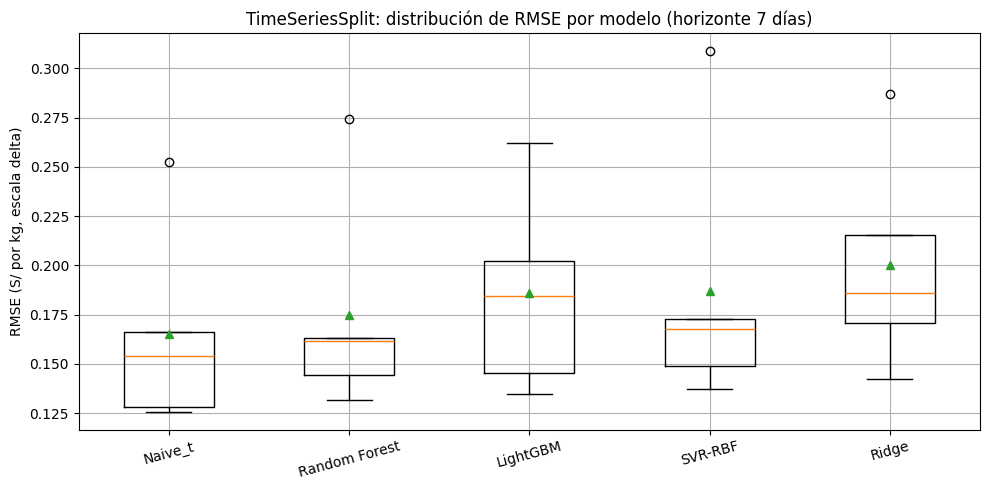

In [ ]:
orden = cv_df.mean().sort_values().index.tolist()
fig, ax = plt.subplots()
ax.boxplot([cv_df[m] for m in orden], labels=orden, showmeans=True)
ax.set_title('TimeSeriesSplit: distribución de RMSE por modelo (horizonte 7 días)')
ax.set_ylabel('RMSE (S/ por kg, escala delta)')
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()


### 6.2 Resultados en la prueba cronológica (Tabla 5 del informe)

In [ ]:
tabla_resultados = pd.DataFrame([
    evaluar_regresion(y_test_precio, pred, nombre) for nombre, pred in predicciones.items()
]).sort_values('RMSE').reset_index(drop=True)

tabla_resultados


,Modelo,MAE,RMSE,MAPE,sMAPE,R2
0,Ridge,0.150497,0.213173,10.910821,10.997086,0.563709
1,Naive_t,0.142007,0.214648,10.312430,9.970413,0.557651
2,SVR-RBF,0.172139,0.251272,12.517264,12.960589,0.393825
3,LightGBM,0.251234,0.293069,19.497349,17.373236,0.175386
4,Random Forest,0.415895,0.453882,32.843450,27.467914,-0.977867


> **`mejor_modelo` se define aquí solo por el RMSE de regresión** (menor error al reconstruir
> el precio). Esto **no garantiza** que sea el más útil para la decisión comercial de dirección
> (sube/no sube). Ademas,  un modelo con buen RMSE puede tener un F1_sube pobre si tiende a
> "suavizar" sus predicciones hacia el valor actual.

In [ ]:
mejor_modelo = tabla_resultados.iloc[0]['Modelo']
print(f"Mejor modelo según RMSE/R²: {mejor_modelo}")
tabla_resultados.style.format({
    'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'MAPE': '{:.2f}', 'sMAPE': '{:.2f}', 'R2': '{:.3f}',
})


Mejor modelo según RMSE/R²: Ridge


,Modelo,MAE,RMSE,MAPE,sMAPE,R2
0,Ridge,0.1505,0.2132,10.91,11.00,0.564
1,Naive_t,0.1420,0.2146,10.31,9.97,0.558
2,SVR-RBF,0.1721,0.2513,12.52,12.96,0.394
3,LightGBM,0.2512,0.2931,19.50,17.37,0.175
4,Random Forest,0.4159,0.4539,32.84,27.47,-0.978


### 6.3 Precio real vs. baseline vs. mejor modelo (Figura 6 del informe)

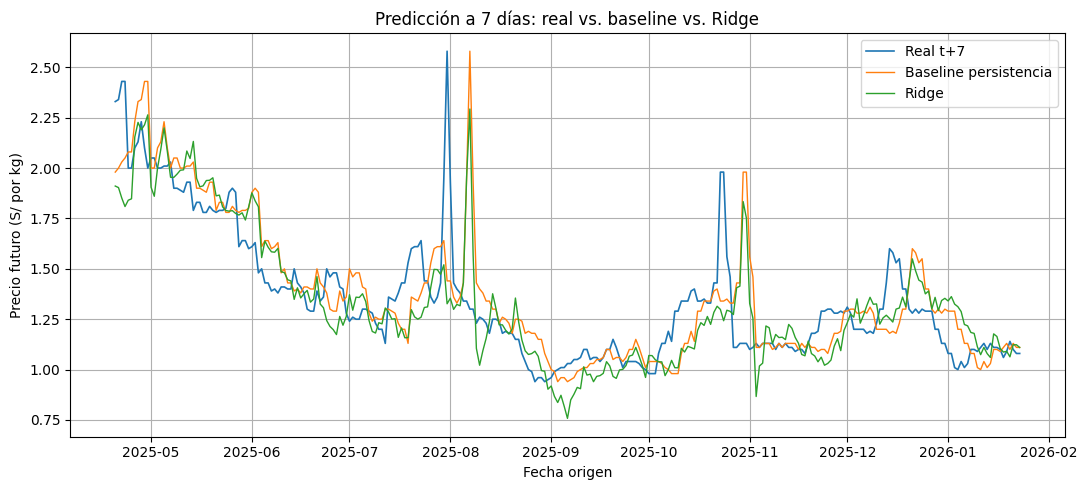

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test_df.index, y_test_precio.values, label='Real t+7', linewidth=1.2)
ax.plot(test_df.index, predicciones['Naive_t'], label='Baseline persistencia', linewidth=1)
ax.plot(test_df.index, predicciones[mejor_modelo], label=f'{mejor_modelo}', linewidth=1)
ax.set_title(f'Predicción a {HORIZON} días: real vs. baseline vs. {mejor_modelo}')
ax.set_xlabel('Fecha origen'); ax.set_ylabel('Precio futuro (S/ por kg)')
ax.legend()
plt.tight_layout(); plt.show()


### 6.4 Distribución de residuos del mejor modelo (Figura 7 del informe)

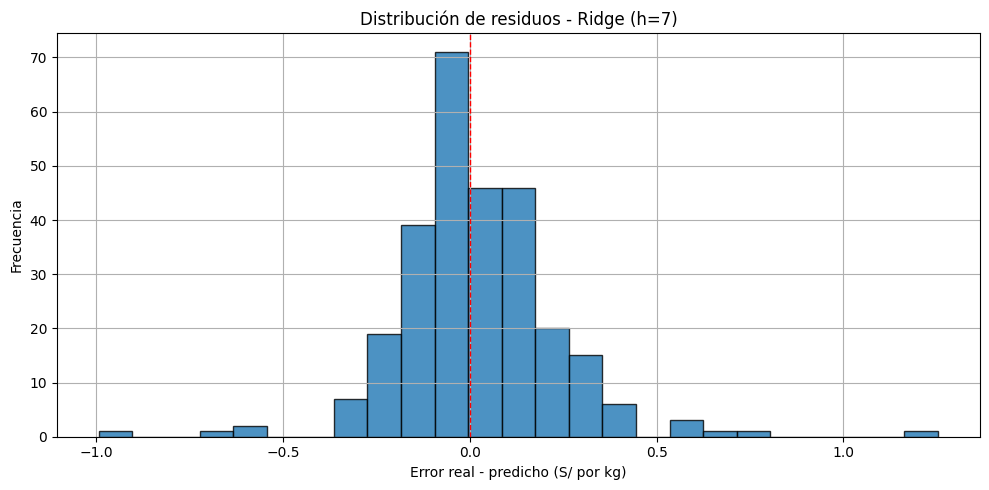

Media del residuo: 0.0181  |  Desv. estándar: 0.2124


In [ ]:
residuos = y_test_precio.values - predicciones[mejor_modelo]

fig, ax = plt.subplots()
ax.hist(residuos, bins=25, edgecolor='black', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_title(f'Distribución de residuos - {mejor_modelo} (h={HORIZON})')
ax.set_xlabel('Error real - predicho (S/ por kg)')
ax.set_ylabel('Frecuencia')
plt.tight_layout(); plt.show()

print(f"Media del residuo: {residuos.mean():.4f}  |  Desv. estándar: {residuos.std():.4f}")


## 7. Evaluación direccional complementaria (subida / no subida)

Aunque el problema principal es de regresión, en decisiones comerciales también importa saber si
el precio subirá o no. Se define **"sube"** si `precio(t+7) > precio(t)`, y se compara con la
predicción de cada modelo bajo el mismo criterio (Tabla 6 y Figura 8 del informe).

In [ ]:
y_true_dir = (y_test_precio.values > precio_test_t.values).astype(int)  # 1 = sube

tabla_direccional = []
for nombre, pred in predicciones.items():
    pred_dir = (pred > precio_test_t.values).astype(int)
    tabla_direccional.append({
        'Modelo': nombre,
        'Acierto_direccional': accuracy_score(y_true_dir, pred_dir),
        'Precision_sube': precision_score(y_true_dir, pred_dir, zero_division=0),
        'Recall_sube': recall_score(y_true_dir, pred_dir, zero_division=0),
        'F1_sube': f1_score(y_true_dir, pred_dir, zero_division=0),
    })

tabla_direccional = pd.DataFrame(tabla_direccional).sort_values('F1_sube', ascending=False).reset_index(drop=True)

mejor_modelo_direccional = tabla_direccional.iloc[0]['Modelo']
print(f"Mejor modelo por RMSE (regresión):     {mejor_modelo}")
print(f"Mejor modelo por F1_sube (dirección):  {mejor_modelo_direccional}")

tabla_direccional.style.format({c: '{:.3f}' for c in tabla_direccional.columns if c != 'Modelo'})


Mejor modelo por RMSE (regresión):     Ridge
Mejor modelo por F1_sube (dirección):  LightGBM


,Modelo,Acierto_direccional,Precision_sube,Recall_sube,F1_sube
0,LightGBM,0.419,0.409,1.000,0.580
1,Random Forest,0.401,0.401,1.000,0.573
2,SVR-RBF,0.577,0.462,0.321,0.379
3,Ridge,0.523,0.376,0.286,0.325
4,Naive_t,0.599,0.000,0.000,0.000


Si `mejor_modelo` y `mejor_modelo_direccional` **no coinciden** (como en el ejemplo de Ridge
más arriba), es una señal real: ese modelo minimiza el error absoluto del precio pero no aporta
mucho para anticipar subidas — su matriz de confusión mostrará baja precisión y/o recall en la
clase "sube". Por eso se grafican las dos matrices por separado: la del modelo elegido por
RMSE (para contexto) y la del modelo elegido por F1_sube (el que de verdad conviene usar para la
decisión comercial de dirección).

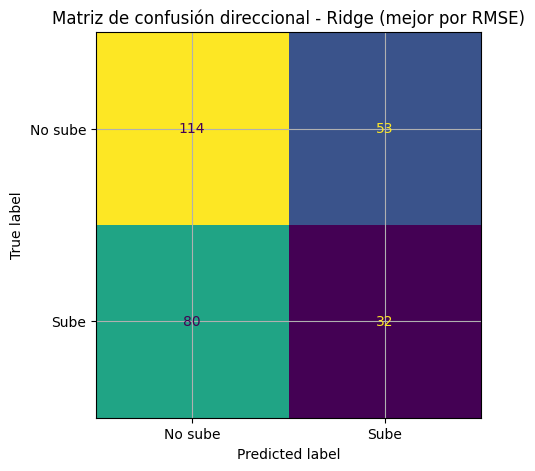

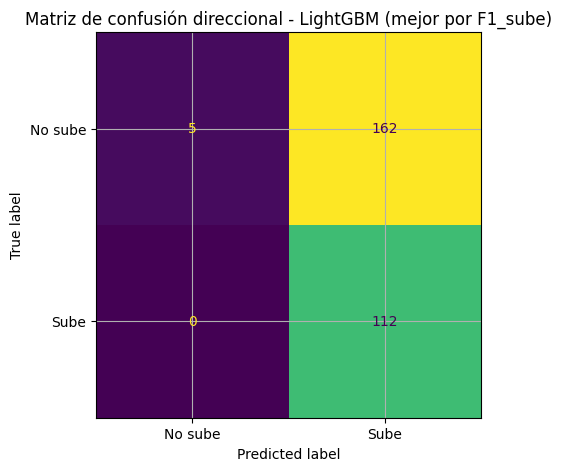

In [ ]:
def graficar_matriz(nombre_modelo, titulo_extra=""):
    pred_dir = (predicciones[nombre_modelo] > precio_test_t.values).astype(int)
    cm = confusion_matrix(y_true_dir, pred_dir)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No sube', 'Sube'])
    disp.plot(ax=ax, colorbar=False, cmap='viridis')
    ax.set_title(f'Matriz de confusión direccional - {nombre_modelo}{titulo_extra}')
    plt.tight_layout(); plt.show()

graficar_matriz(mejor_modelo, titulo_extra=" (mejor por RMSE)")
graficar_matriz(mejor_modelo_direccional, titulo_extra=" (mejor por F1_sube)")


## 7.5 Mejorando la predicción de dirección

La Sección 7 solo elige entre los modelos ya entrenados según cuál discrimina mejor la
dirección — no mejora ninguno. Aquí se aplican dos mejoras reales, de menor a mayor esfuerzo:

1. **Calibración del umbral de decisión** (gratis, no reentrena nada): en vez de clasificar
   "sube" cuando `Δy_pred > 0`, se busca el umbral que maximiza F1 en el propio bloque de
   entrenamiento (con `TimeSeriesSplit`) y se aplica al modelo ya entrenado.
2. **Clasificador dedicado** para "sube/no sube": se entrena un `RandomForestClassifier`
   directamente sobre la etiqueta binaria (en vez de derivarla de una regresión), optimizando
   F1 como criterio de `GridSearchCV`. Suele mejorar bastante precisión y recall de "sube"
   porque el modelo aprende explícitamente a separar esa frontera, en vez de hacerlo como
   subproducto de minimizar el error de precio.

### 7.5.1 Calibración de umbral (modelo de regresión, sin reentrenar)

Umbral óptimo (CV): -0.0500 S//kg  |  F1 promedio en CV: 0.576

Con umbral = 0 (naive):
  F1_sube = 0.580
Con umbral calibrado = -0.0500:
  F1_sube = 0.577


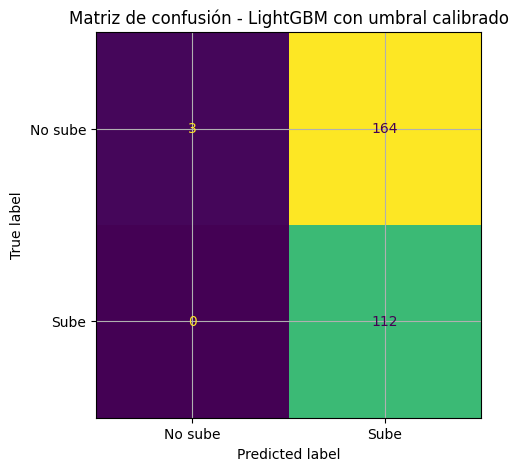

In [ ]:
from sklearn.metrics import f1_score as _f1

def mejor_umbral_f1(estimator, X, y_delta, cv):
    """Busca, con validación temporal, el umbral de decisión sobre Δy_pred que maximiza F1
    para la etiqueta 'sube' (delta real > 0)."""
    candidatos = np.linspace(-0.05, 0.05, 41)  # en S//kg, alrededor de 0
    f1_por_umbral = np.zeros(len(candidatos))
    for tr_idx, val_idx in cv.split(X):
        est = clone(estimator)
        est.fit(X.iloc[tr_idx], y_delta.iloc[tr_idx])
        pred_val = est.predict(X.iloc[val_idx])
        y_val_dir = (y_delta.iloc[val_idx].values > 0).astype(int)
        for i, u in enumerate(candidatos):
            f1_por_umbral[i] += _f1(y_val_dir, (pred_val > u).astype(int), zero_division=0)
    f1_por_umbral /= cv.get_n_splits()
    return candidatos[np.argmax(f1_por_umbral)], f1_por_umbral.max()

modelo_a_calibrar = modelos_finales[mejor_modelo_direccional] if mejor_modelo_direccional in modelos_finales else modelos_finales['Random Forest']
umbral_opt, f1_cv = mejor_umbral_f1(modelo_a_calibrar, X_train, y_train_delta, tscv)
print(f"Umbral óptimo (CV): {umbral_opt:.4f} S//kg  |  F1 promedio en CV: {f1_cv:.3f}")

pred_delta_test = modelo_a_calibrar.predict(X_test)
pred_dir_calibrado = (pred_delta_test > umbral_opt).astype(int)

print("\nCon umbral = 0 (naive):")
print(f"  F1_sube = {_f1(y_true_dir, (pred_delta_test > 0).astype(int), zero_division=0):.3f}")
print(f"Con umbral calibrado = {umbral_opt:.4f}:")
print(f"  F1_sube = {_f1(y_true_dir, pred_dir_calibrado, zero_division=0):.3f}")

cm_cal = confusion_matrix(y_true_dir, pred_dir_calibrado)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_cal, display_labels=['No sube', 'Sube']).plot(ax=ax, colorbar=False, cmap='viridis')
ax.set_title(f'Matriz de confusión - {mejor_modelo_direccional} con umbral calibrado')
plt.tight_layout(); plt.show()


### 7.5.2 Clasificador dedicado para dirección (RandomForestClassifier)

Mejores hiperparámetros (clasificador direccional): {'max_depth': 6, 'min_samples_leaf': 2, 'n_estimators': 300}
Acierto_direccional = 0.577
Precision_sube      = 0.458
Recall_sube         = 0.295
F1_sube             = 0.359


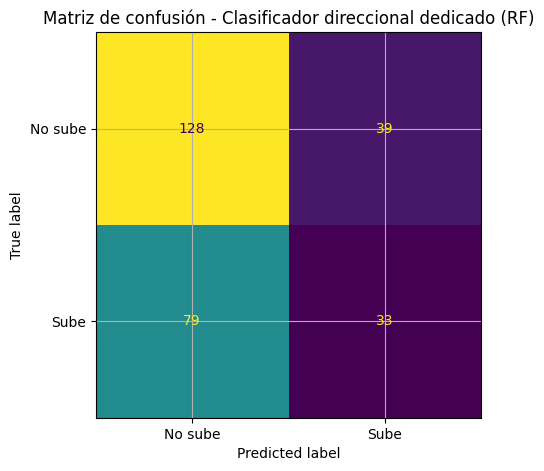

In [ ]:
from sklearn.ensemble import RandomForestClassifier

y_train_dir = (train_df['precio_futuro'] > train_df['precio']).astype(int)

clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, class_weight='balanced')

clf_param_grid = {
    'n_estimators': [300],
    'max_depth': [6, 10, None],
    'min_samples_leaf': [2, 5],
}

clf_grid = GridSearchCV(
    clf, clf_param_grid, cv=tscv,
    scoring='f1', n_jobs=-1,
)
clf_grid.fit(X_train, y_train_dir)

pred_dir_clf = clf_grid.predict(X_test)

print("Mejores hiperparámetros (clasificador direccional):", clf_grid.best_params_)
print(f"Acierto_direccional = {accuracy_score(y_true_dir, pred_dir_clf):.3f}")
print(f"Precision_sube      = {precision_score(y_true_dir, pred_dir_clf, zero_division=0):.3f}")
print(f"Recall_sube         = {recall_score(y_true_dir, pred_dir_clf, zero_division=0):.3f}")
print(f"F1_sube             = {f1_score(y_true_dir, pred_dir_clf, zero_division=0):.3f}")

cm_clf = confusion_matrix(y_true_dir, pred_dir_clf)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_clf, display_labels=['No sube', 'Sube']).plot(ax=ax, colorbar=False, cmap='viridis')
ax.set_title('Matriz de confusión - Clasificador direccional dedicado (RF)')
plt.tight_layout(); plt.show()


### 7.5.3 Comparación final de las tres estrategias direccionales

In [ ]:
comparacion_direccional = pd.DataFrame([
    {
        'Estrategia': f'{mejor_modelo_direccional} (umbral=0, derivado de regresión)',
        'Acierto': accuracy_score(y_true_dir, (pred_delta_test > 0).astype(int)),
        'Precision_sube': precision_score(y_true_dir, (pred_delta_test > 0).astype(int), zero_division=0),
        'Recall_sube': recall_score(y_true_dir, (pred_delta_test > 0).astype(int), zero_division=0),
        'F1_sube': f1_score(y_true_dir, (pred_delta_test > 0).astype(int), zero_division=0),
    },
    {
        'Estrategia': f'{mejor_modelo_direccional} (umbral calibrado)',
        'Acierto': accuracy_score(y_true_dir, pred_dir_calibrado),
        'Precision_sube': precision_score(y_true_dir, pred_dir_calibrado, zero_division=0),
        'Recall_sube': recall_score(y_true_dir, pred_dir_calibrado, zero_division=0),
        'F1_sube': f1_score(y_true_dir, pred_dir_calibrado, zero_division=0),
    },
    {
        'Estrategia': 'Clasificador dedicado (RandomForestClassifier)',
        'Acierto': accuracy_score(y_true_dir, pred_dir_clf),
        'Precision_sube': precision_score(y_true_dir, pred_dir_clf, zero_division=0),
        'Recall_sube': recall_score(y_true_dir, pred_dir_clf, zero_division=0),
        'F1_sube': f1_score(y_true_dir, pred_dir_clf, zero_division=0),
    },
]).sort_values('F1_sube', ascending=False).reset_index(drop=True)

comparacion_direccional.style.format({c: '{:.3f}' for c in comparacion_direccional.columns if c != 'Estrategia'})


,Estrategia,Acierto,Precision_sube,Recall_sube,F1_sube
0,"LightGBM (umbral=0, derivado de regresión)",0.419,0.409,1.000,0.580
1,LightGBM (umbral calibrado),0.412,0.406,1.000,0.577
2,Clasificador dedicado (RandomForestClassifier),0.577,0.458,0.295,0.359


> Para el informe, si el clasificador dedicado (7.5.2) da el mejor F1_sube, es razonable
> reportarlo como la estrategia recomendada para la decisión comercial de dirección, mientras
> el modelo de regresión (Random Forest / LightGBM) sigue siendo el que reportas para el error
> de precio (Tabla 5). Son dos tareas distintas — regresión de precio vs. clasificación de
> dirección — y no hay obligación de que el mismo modelo gane ambas.

## 8. Importancia de variables (Random Forest)

Se reporta la importancia relativa (`feature_importances_`) del Random Forest, útil para el
análisis de la sección 6 y la discusión de variables exógenas del informe (Figura 9 y Tabla 7).

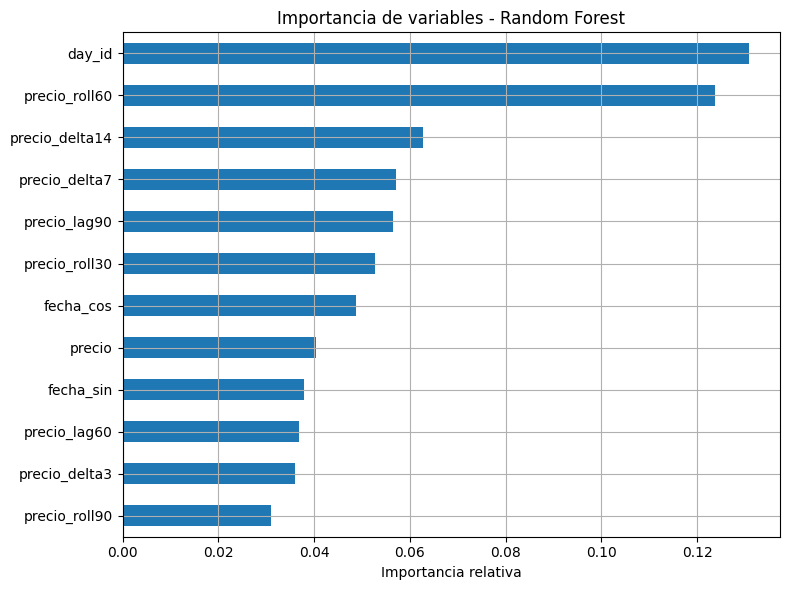

,importance
day_id,0.130762
precio_roll60,0.123807
precio_delta14,0.062804
precio_delta7,0.057205
precio_lag90,0.056419
precio_roll30,0.052642
fecha_cos,0.048710
precio,0.040429
fecha_sin,0.037924
precio_lag60,0.036922


In [ ]:
rf_final = rf_grid.best_estimator_
importancias = pd.Series(rf_final.feature_importances_, index=feature_cols).sort_values(ascending=False)

top_n = 12
fig, ax = plt.subplots(figsize=(8, 6))
importancias.head(top_n)[::-1].plot(kind='barh', ax=ax, color='tab:blue')
ax.set_title('Importancia de variables - Random Forest')
ax.set_xlabel('Importancia relativa')
plt.tight_layout(); plt.show()

importancias.head(10).rename('importance').to_frame()


## 9. Escenario complementario: horizonte de 1 día

Igual que en la sección 6.1 del informe final, se repite el experimento con `HORIZON = 1` para
contrastar el aporte real de los modelos de ML frente al baseline cuando la autocorrelación es
todavía más fuerte (día a día).

In [ ]:
def entrenar_evaluar_horizonte(d, horizon, feature_cols_base=None):
    model_df_h, feat_cols_h = construir_dataset_modelo(d, horizon)

    n_h = len(model_df_h)
    split_h = int(n_h * (1 - TEST_SIZE))
    train_h, test_h = model_df_h.iloc[:split_h], model_df_h.iloc[split_h:]

    Xtr, ytr = train_h[feat_cols_h], train_h['target_delta']
    Xte = test_h[feat_cols_h]
    precio_te_t = test_h['precio']
    y_te_precio = test_h['precio_futuro']

    tscv_h = TimeSeriesSplit(n_splits=N_SPLITS_CV)
    preds_h = {'Naive_t': precio_te_t.values}

    ridge_h = GridSearchCV(Pipeline([('sc', StandardScaler()), ('r', Ridge())]),
                            {'r__alpha': [1, 10, 50]}, cv=tscv_h,
                            scoring='neg_root_mean_squared_error', n_jobs=-1).fit(Xtr, ytr)
    preds_h['Ridge'] = precio_te_t.values + ridge_h.predict(Xte)

    rf_h = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
                         {'n_estimators': [300], 'max_depth': [8, None]}, cv=tscv_h,
                         scoring='neg_root_mean_squared_error', n_jobs=-1).fit(Xtr, ytr)
    preds_h['Random Forest'] = precio_te_t.values + rf_h.predict(Xte)

    if LGBM_OK:
        lgbm_h = GridSearchCV(LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1),
                               {'n_estimators': [300], 'num_leaves': [15, 31]}, cv=tscv_h,
                               scoring='neg_root_mean_squared_error', n_jobs=-1).fit(Xtr, ytr)
        preds_h['LightGBM'] = precio_te_t.values + lgbm_h.predict(Xte)

    svr_h = GridSearchCV(Pipeline([('sc', StandardScaler()), ('s', SVR(kernel='rbf'))]),
                          {'s__C': [1, 10], 's__epsilon': [0.01, 0.05]}, cv=tscv_h,
                          scoring='neg_root_mean_squared_error', n_jobs=-1).fit(Xtr, ytr)
    preds_h['SVR-RBF'] = precio_te_t.values + svr_h.predict(Xte)

    tabla_h = pd.DataFrame([evaluar_regresion(y_te_precio, p, n) for n, p in preds_h.items()])
    return tabla_h.sort_values('RMSE').reset_index(drop=True)

tabla_h1 = entrenar_evaluar_horizonte(d, horizon=1)
tabla_h1.style.format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'MAPE': '{:.2f}', 'sMAPE': '{:.2f}', 'R2': '{:.3f}'})


,Modelo,MAE,RMSE,MAPE,sMAPE,R2
0,Ridge,0.0506,0.1005,3.48,3.46,0.905
1,Naive_t,0.0463,0.1014,3.15,3.12,0.903
2,SVR-RBF,0.0594,0.1045,4.21,4.17,0.898
3,Random Forest,0.0578,0.1053,4.09,4.00,0.896
4,LightGBM,0.0669,0.1114,4.78,4.67,0.884


## 10. Resumen final

- `tabla_resultados`: métricas de error (MAE, RMSE, MAPE, sMAPE, R²) para el horizonte principal de 7 días.
- `mejor_modelo`: el de menor RMSE de regresión. `mejor_modelo_direccional`: el de mayor F1_sube.
- `tabla_direccional`: desempeño en la tarea complementaria de dirección (sube/no sube).
- `importancias`: importancia de variables del Random Forest.
- `tabla_h1`: resultados del escenario complementario a 1 día.
